In [2]:
import torch
from google.colab import drive
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def create_tile_level_embeddings(raw_embedding):
  # mask sentinel patch embeddings in the averaging
  norms = torch.linalg.norm(raw_embedding, dim=-1)
  mask_bad = norms > 100.0
  w = (~mask_bad).float().unsqueeze(-1)
  # average over patches
  tile_embeddings = (raw_embedding * w).sum(dim=2) / w.sum(dim=2).clamp_min(1.0)
  print(f"Output dimensions: {tile_embeddings.shape}")
  return tile_embeddings


def lulc_composition_to_array(metadata):
  all_class_cols = [col for col in metadata.columns if "class" in col]
  selected_cols = all_class_cols[1:] + ['year', 'spatial_id_int']
  grouped = metadata[selected_cols].groupby(['year', 'spatial_id_int']).sum()

  num_years = grouped.index.get_level_values('year').nunique()
  num_tiles = grouped.index.get_level_values('spatial_id_int').nunique()
  num_dimensions = grouped.shape[1]
  numpy_array = grouped.to_numpy()
  tensor = torch.from_numpy(numpy_array)
  reshaped_tensor = tensor.view(num_years, num_tiles, num_dimensions)
  reshaped_tensor = reshaped_tensor / (reshaped_tensor.sum(dim=-1, keepdim=True) + 1e-8)
  ground_truth_array = reshaped_tensor.float()

  return ground_truth_array


def compute_suburb_tile_movement(suburb_tiles):
    # Y = Years, T = Tiles, D = Dimensions
    Y, T, D = suburb_tiles.shape

    # 1. Average the tiles first to get the suburb's 'identity' per year
    # Shape: [Y, T, D] -> [Y, D]
    suburb_yearly_identity = torch.mean(suburb_tiles, dim=1)

    # 2. Net Displacement: Distance between the start (2015) and end (2024)
    # This measures the straight-line "Regime Shift"
    net_displacement = torch.linalg.norm(suburb_yearly_identity[-1] - suburb_yearly_identity[0])

    # 3. Velocity: Year-to-year deltas of the suburb's average position
    velocity_vectors = suburb_yearly_identity[1:] - suburb_yearly_identity[:-1]

    # 4. Magnitude of annual change
    suburb_v_norms = torch.linalg.norm(velocity_vectors, dim=-1)

    total_path_length = torch.sum(suburb_v_norms)

    # 5. Calculate mean rate of change and change smoothness
    v_mean = torch.mean(suburb_v_norms)

    efficiency = net_displacement / (total_path_length + 1e-8)

    # 6. Mean rate of change, overall change magnitude, and smoothness of trajectory
    trajectory_profile = [v_mean, net_displacement, efficiency]

    return trajectory_profile

def KNN_cluster(X):
  scaler = StandardScaler()
  scaled_features = scaler.fit_transform(X)

  kmeans = KMeans(n_clusters=4, random_state=42)
  clusters = kmeans.fit_predict(scaled_features)
  return clusters

def create_trajectory_df(suburb_names, clusters, X):
  df_3d_plot = pd.DataFrame({
      'mean_velocity': X[:, 0],
      'net_displacement': X[:, 1],
      'path_efficiency': X[:, 2],
      'Cluster': clusters,
      'Suburb': suburb_names
  })
  return df_3d_plot

def display_clustering(df_3d_plot, cluster_type):

  fig = plt.figure(figsize=(10, 8))
  ax = fig.add_subplot(111, projection='3d')

  unique_clusters = sorted(df_3d_plot['Cluster'].unique())
  colors_palette = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))
  cluster_to_color = {c: colors_palette[i] for i, c in enumerate(unique_clusters)}

  for cluster_id in unique_clusters:
      cluster_color = cluster_to_color[cluster_id]
      subset = df_3d_plot[df_3d_plot['Cluster'] == cluster_id]

      # Plot each cluster with a single label for the legend
      ax.scatter(subset['mean_velocity'],
                subset['net_displacement'],
                subset['path_efficiency'],
                c=[cluster_color],
                s=60, alpha=0.8, label=f'Cluster {cluster_id}')

  # Add suburb names to the plot
  for i, row in df_3d_plot.iterrows():
      ax.text(row['mean_velocity'], row['net_displacement'], row['path_efficiency'],
              row['Suburb'], size=8, zorder=1, color='k')

  ax.set_xlabel('Avg Yearly Change')
  ax.set_ylabel('Net Displacement')
  ax.set_zlabel('Path Efficiency', labelpad=15)
  ax.set_title(f'Trajectory Analysis of Suburbs ({cluster_type})', fontsize=16)

  ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1),
            fontsize='small', title='Clusters',
            fancybox=True, shadow=True, title_fontsize='medium')

  plt.tight_layout(rect=[0, 0, 1, 1])
  plt.show()

In [4]:
# load in data
terramind_project = '/content/drive/MyDrive/Terramind_Blue_Sky_Challenge/'
neighborhood_folders = [entry.name for entry in os.scandir(terramind_project) if entry.is_dir()]
neighborhood_folders.remove('archive')
suburbs = {}
for folder in neighborhood_folders:
  suburb_name = " ".join(folder.split("_")[:-3])

  metadata_path = os.path.join(terramind_project, folder, 'lulc_classes_embeddings_metadata.geojson')
  embedding_path = os.path.join(terramind_project, folder, 'terramind_lulc_embeddings.pt')

  suburbs[suburb_name] = {}
  try:
    print(f'Processing {suburb_name}')
    suburbs[suburb_name]['lulc_percentages'] = lulc_composition_to_array(gpd.read_file(metadata_path))
    suburbs[suburb_name]['tile_embeddings'] = create_tile_level_embeddings(torch.load(embedding_path)['embeddings'])
  except Exception as e:
    print(f"Error loading data for suburb '{suburb_name}' in folder '{folder}': {e}. Skipping this folder.")
    del suburbs[suburb_name]
    continue

Processing Conroe
Output dimensions: torch.Size([11, 132, 768])
Processing Magnolia
Output dimensions: torch.Size([11, 8, 768])
Processing Montgomery
Output dimensions: torch.Size([11, 2, 768])
Processing Pearland
Output dimensions: torch.Size([11, 50, 768])
Processing Katy
Output dimensions: torch.Size([11, 16, 768])
Processing Sugar Land
Output dimensions: torch.Size([11, 35, 768])
Processing The Woodlands
Output dimensions: torch.Size([11, 42, 768])
Processing Fulshear
Output dimensions: torch.Size([11, 12, 768])
Processing Barrett
Output dimensions: torch.Size([11, 4, 768])
Processing Four Corners
Output dimensions: torch.Size([11, 1, 768])
Processing Spring
Output dimensions: torch.Size([11, 20, 768])
Processing Pasadena
Output dimensions: torch.Size([11, 99, 768])
Processing South Houston
Output dimensions: torch.Size([11, 1, 768])
Processing Stafford
Output dimensions: torch.Size([11, 6, 768])
Processing Mission Bend
Output dimensions: torch.Size([11, 1, 768])
Processing Humble


In [ ]:
# compute embedding movement and lulc % change
embedding_changes = []
lulc_changes = []

for suburb in suburbs.keys():
  embedding_changes.append(compute_suburb_tile_movement(suburbs[suburb]['tile_embeddings']))
  lulc_changes.append(compute_suburb_tile_movement(suburbs[suburb]['lulc_percentages']))

X_embeddings = np.vstack(embedding_changes)
X_lulc = np.vstack(lulc_changes)

In [ ]:
# cluster embeddings and lulc change trajectories
embedding_clusters = KNN_cluster(X_embeddings)
lulc_clusters = KNN_cluster(X_lulc)

In [ ]:
# store results in a df
embedding_trajectory_df = create_trajectory_df(list(suburbs.keys()), embedding_clusters, X_embeddings)
lulc_trajectory_df = create_trajectory_df(list(suburbs.keys()), lulc_clusters, X_lulc)

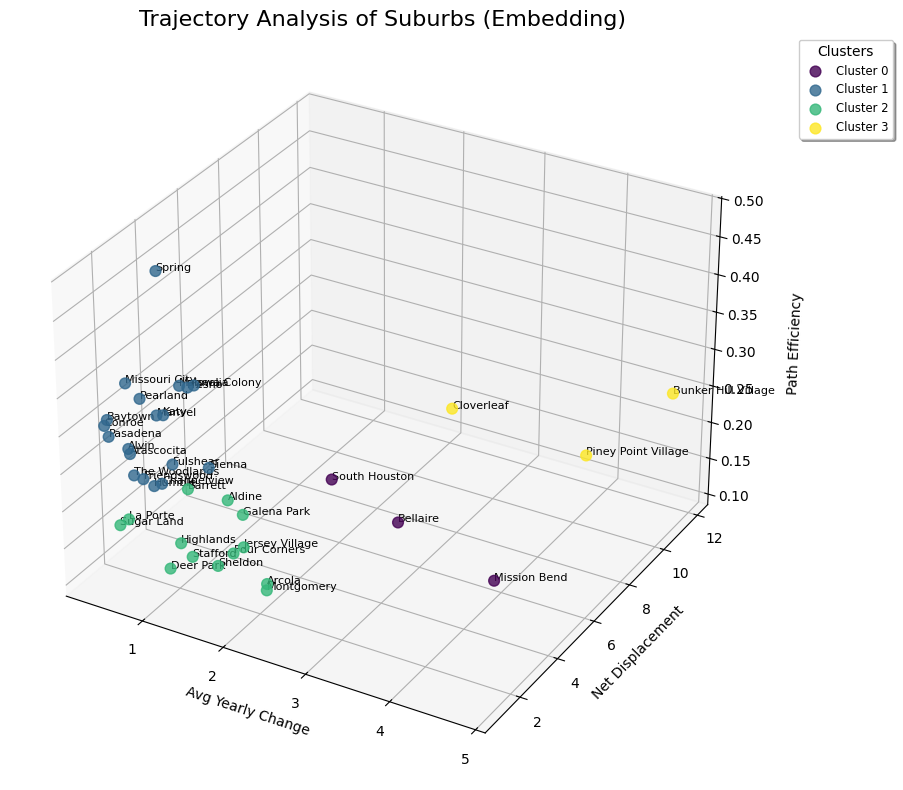

In [ ]:
# visualize
display_clustering(embedding_trajectory_df, 'Embedding')

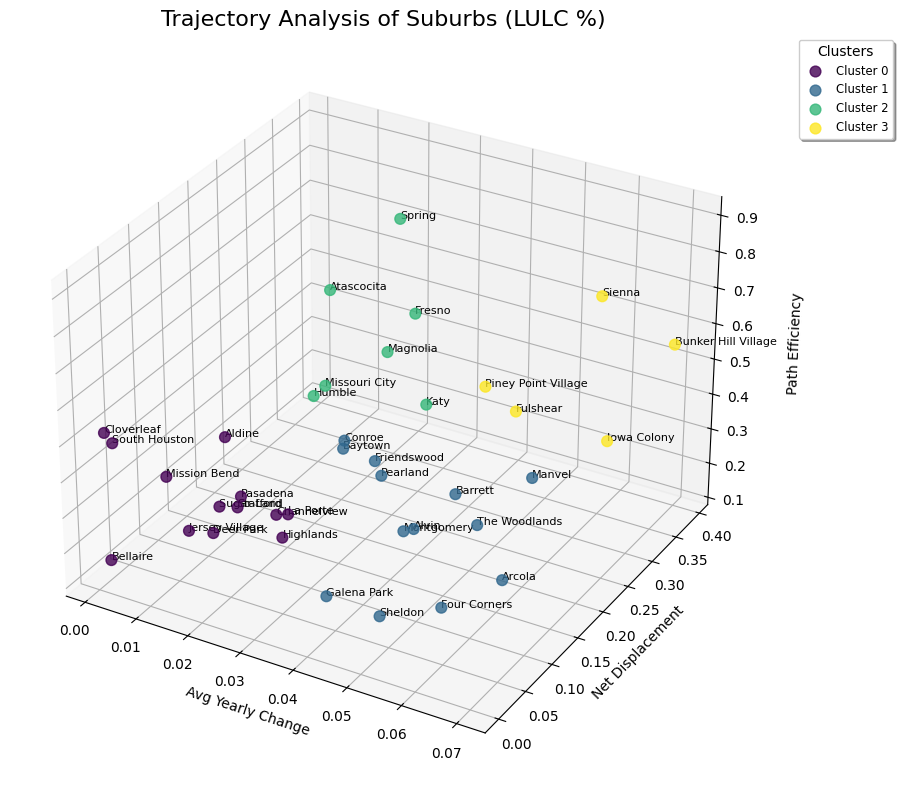

In [ ]:
display_clustering(lulc_trajectory_df, 'LULC %')

In [ ]:
embedding_trajectory_df.to_csv('embedding_traj.csv')

In [ ]:
lulc_trajectory_df.to_csv('lulc_traj.csv')